# High-Level Backtesting of the ICT Strategy

In [1]:
# imports
import time
import pandas as pd
from nautilus_trader.backtest.config import BacktestVenueConfig, BacktestDataConfig, BacktestRunConfig
from nautilus_trader.backtest.engine import BacktestResult, BacktestEngine, BacktestEngineConfig
from nautilus_trader.backtest.node import BacktestNode
from nautilus_trader.common.config import LoggingConfig
from nautilus_trader.core.datetime import dt_to_unix_nanos
from nautilus_trader.model import BarType, Bar, Venue, InstrumentId
from nautilus_trader.model.enums import OmsType
from nautilus_trader.persistence.catalog import ParquetDataCatalog
from nautilus_trader.persistence.config import DataCatalogConfig
from nautilus_trader.test_kit.providers import TestInstrumentProvider
from nautilus_trader.trading import trader
from nautilus_trader.trading.config import ImportableStrategyConfig
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [ ]:
from core.enums import MoneyManagementType

catalog = ParquetDataCatalog("../catalog")

start_ns = dt_to_unix_nanos(pd.Timestamp("2025-01-01"))
#start_ns = dt_to_unix_nanos(pd.Timestamp("2025-07-09"))
end_ns = dt_to_unix_nanos(pd.Timestamp("2025-10-22"))

instrument = TestInstrumentProvider.es_future(2025, 12)
instrument_id = instrument.id.value

# Configure backtesting
venue = BacktestVenueConfig(
    name="GLBX",
    oms_type=OmsType.NETTING,
    account_type="MARGIN",
    base_currency="USD",
    starting_balances=["30_000 USD"],
)

# Configure a catalog for a live system
catalog_cfg = DataCatalogConfig(
    path=str(catalog.path),
    fs_protocol="file",
    name="local"
)

base_bar_type = BarType.from_str(f"{instrument_id}-1-MINUTE-LAST-EXTERNAL")
weekly_bar_type = BarType.from_str(f"{instrument_id}-1-WEEK-LAST-INTERNAL@1-MINUTE-EXTERNAL")
daily_bar_type = BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL")

data = BacktestDataConfig(
    catalog_path=str(catalog.path),
    catalog_fs_protocol="file",
    data_cls=Bar,
    bar_types=[base_bar_type],
    instrument_id=instrument_id,
    start_time=start_ns,
    end_time=end_ns
)

engine = BacktestEngineConfig(
    strategies=[
        ImportableStrategyConfig(
            strategy_path="strategies.ict.ict_strategy:ICTStrategy",
            config_path="strategies.ict.ict_strategy:ICTStrategyConfig",
            config={
                "instrument_id": instrument_id,
                "base_bar_type": base_bar_type,
                "weekly_bar_type": weekly_bar_type,
                "daily_bar_type": daily_bar_type,
                "is_backtest": True,

                # ------------- Liquidity Pool Search -------------
                "liquidity_pool_bar_type": BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_lower_timeframe_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_time_delta": pd.Timedelta(hours=24),
                "liquidity_pool_min_lower_timeframe_count": 3,
                "liquidity_pool_extremums_count": 1,
                "liquidity_pool_upper_period_window": 3,
                "liquidity_pool_lower_period_window": 3,

                # ------------- Turtle Soup -------------
                "turtle_soup_analysis_chain_bar_type": [
                    BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-15-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-5-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                ],
                "turtle_soup_stop_loss_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "turtle_soup_bars_count": 4,
                "retries_count_on_stop_out": 3,
                "sl_shift": 4.0,

                # ------------- Risk/Reward -------------
                "risk_reward_ratio": 2.0,

                # ------------- Expected Target -------------
                "expected_target_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "expected_target_left": 10,
                "expected_target_right": 10,

                # ------------- Liquidity Pool Reuse -------------
                "liquidity_pool_reuse_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_uses_count": 1,

                # ------------- SMA Exit -------------
                "sma_exit_bar_type": BarType.from_str(f"{instrument_id}-30-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "sma_exit_period": 10,

                # ------------- Money Management -------------
                "money_management_type": MoneyManagementType.FIXED_LOT,
                "fixed_lot": 10.0,
                "fixed_risk_percent": 1.0,
            },
        ),
    ],
    logging=LoggingConfig(log_level="ERROR"),
    catalogs=[catalog_cfg]
)

config = BacktestRunConfig(
    engine=engine,
    venues=[venue],
    data=[data],
)

node = BacktestNode(configs=[config])

# run backtesting
elapsed_start = time.perf_counter()
# Runs one or many configs synchronously
results: list[BacktestResult] = node.run()
elapsed_end = time.perf_counter()

print(f"Elapsed time: {elapsed_end - elapsed_start:.6f} seconds")

Elapsed time: 15.908838 seconds


In [3]:
result = results[0]

print(f"{'='*60}")
print(f"BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Trader ID:        {result.trader_id}")
print(f"Run ID:           {result.run_id}")
print(f"Backtest Period:  {pd.Timestamp(result.backtest_start, unit='ns')} → {pd.Timestamp(result.backtest_end, unit='ns')}")
print(f"Elapsed Time:     {result.elapsed_time / 1e9:.2f} seconds")
print(f"Iterations:       {result.iterations:,}")
print(f"Total Orders:     {result.total_orders}")
print(f"Total Positions:  {result.total_positions}")

print(f"\n{'='*60}")
print(f"PNL STATISTICS (USD)")
print(f"{'='*60}")
pnl = result.stats_pnls.get('USD', {})
print(f"PnL (total):      ${pnl.get('PnL (total)', 0):,.2f}")
print(f"PnL% (total):     {pnl.get('PnL% (total)', 0):.2f}%")
print(f"Expectancy:       ${pnl.get('Expectancy', 0):,.2f}")
print(f"Win Rate:         {pnl.get('Win Rate', 0)*100:.2f}%")
print(f"Max Winner:       ${pnl.get('Max Winner', 0):,.2f}")
print(f"Avg Winner:       ${pnl.get('Avg Winner', 0):,.2f}")
print(f"Min Winner:       ${pnl.get('Min Winner', 0):,.2f}")
print(f"Max Loser:        ${pnl.get('Max Loser', 0):,.2f}")
print(f"Avg Loser:        ${pnl.get('Avg Loser', 0):,.2f}")
print(f"Min Loser:        ${pnl.get('Min Loser', 0):,.2f}")

print(f"\n{'='*60}")
print(f"RETURN STATISTICS")
print(f"{'='*60}")
ret = result.stats_returns
print(f"Sharpe Ratio (252d):   {ret.get('Sharpe Ratio (252 days)', 0):.4f}")
print(f"Sortino Ratio (252d):  {ret.get('Sortino Ratio (252 days)', 0):.4f}")
print(f"Profit Factor:         {ret.get('Profit Factor', 0):.4f}")
print(f"Returns Volatility:    {ret.get('Returns Volatility (252 days)', 0):.4f}")
print(f"Risk Return Ratio:     {ret.get('Risk Return Ratio', 0):.4f}")
print(f"Avg Return:            {ret.get('Average (Return)', 0)*100:.4f}%")
print(f"Avg Win Return:        {ret.get('Average Win (Return)', 0)*100:.4f}%")
print(f"Avg Loss Return:       {ret.get('Average Loss (Return)', 0)*100:.4f}%")

BACKTEST RESULTS
Trader ID:        BACKTESTER-001
Run ID:           a43df1b0-e311-433a-8499-07a77646e5e4
Backtest Period:  2025-01-01 23:01:00 → 2025-10-20 00:00:00
Elapsed Time:     0.03 seconds
Iterations:       282,241
Total Orders:     198
Total Positions:  79

PNL STATISTICS (USD)
PnL (total):      $605.25
PnL% (total):     2.02%
Expectancy:       $7.66
Win Rate:         35.44%
Max Winner:       $1,195.00
Avg Winner:       $584.71
Min Winner:       $455.00
Max Loser:        $-600.25
Avg Loser:        $-309.15
Min Loser:        $-185.25

RETURN STATISTICS
Sharpe Ratio (252d):   1.7539
Sortino Ratio (252d):  3.8567
Profit Factor:         1.3576
Returns Volatility:    0.1148
Risk Return Ratio:     0.1105
Avg Return:            0.0597%
Avg Win Return:        0.6391%
Avg Loss Return:       -0.2585%


In [4]:
backtest_engine: BacktestEngine = node.get_engine(config.id)
positions = backtest_engine.trader.generate_positions_report()

In [5]:
len(positions)

79

In [6]:
pd.set_option("display.max_rows", 202)   # show all rows
pd.set_option("display.max_columns", None)  # show all cols

# Reduce font size for DataFrame display
from IPython.display import display, HTML
display(HTML("<style>.dataframe { font-size: 12px; }</style>"))


In [7]:
positions

,trader_id,strategy_id,instrument_id,account_id,opening_order_id,closing_order_id,entry,side,quantity,peak_qty,ts_init,ts_opened,ts_last,ts_closed,duration_ns,avg_px_open,avg_px_close,commissions,realized_return,realized_pnl,is_snapshot
position_id,,,,,,,,,,,,,,,,,,,,,
ESZ5.GLBX-ICTStrategy-000-48c9a9fe-20d8-477b-8207-fdb5311e8c89,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250103-194500-001-000-1,O-20250103-204900-001-000-3,SELL,FLAT,0,48,1735933560000000000,2025-01-03 19:46:00+00:00,1735937340000000000,2025-01-03 20:49:00+00:00,3780000000000,5994.500000,5982.250000,[0.00 USD],0.00204,588.00 USD,True
ESZ5.GLBX-ICTStrategy-000-d91cd94b-c22a-4093-a3fb-8340c7422934,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250114-120000-001-000-4,O-20250114-120000-001-000-5,SELL,FLAT,0,14,1736856060000000000,2025-01-14 12:01:00+00:00,1736861520000000000,2025-01-14 13:32:00+00:00,5460000000000,5895.750000,5917.500000,[0.00 USD],-0.00369,-304.50 USD,True
ESZ5.GLBX-ICTStrategy-000-b0673bc7-9260-4454-b912-c7ed1e10ee31,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250114-134500-001-000-6,O-20250114-164500-001-000-8,SELL,FLAT,0,13,1736862360000000000,2025-01-14 13:46:00+00:00,1736873100000000000,2025-01-14 16:45:00+00:00,10740000000000,5905.000000,5854.500000,[0.00 USD],0.00855,656.50 USD,True
ESZ5.GLBX-ICTStrategy-000-46247e0b-c17f-4ee7-bd49-be7093d52b14,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250116-100500-001-000-9,O-20250117-134000-001-000-12,SELL,FLAT,0,42,1737021900000000000,2025-01-16 10:05:00+00:00,1737122700000000000,2025-01-17 14:05:00+00:00,100800000000000,6009.797619,6024.089286,[0.00 USD],-0.00238,-600.25 USD,True
ESZ5.GLBX-ICTStrategy-000-76dd5165-890f-4116-9df8-898a98b2cadc,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250120-141500-001-000-13,O-20250120-141500-001-000-14,SELL,FLAT,0,23,1737382500000000000,2025-01-20 14:15:00+00:00,1737383220000000000,2025-01-20 14:27:00+00:00,720000000000,6051.250000,6064.250000,[0.00 USD],-0.00215,-299.00 USD,True
ESZ5.GLBX-ICTStrategy-000-8f97e4da-a524-4b19-a3e5-9da186b753f3,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250122-010500-001-000-15,O-20250122-010500-001-000-16,SELL,FLAT,0,35,1737507900000000000,2025-01-22 01:05:00+00:00,1737534000000000000,2025-01-22 08:20:00+00:00,26100000000000,6097.500000,6106.000000,[0.00 USD],-0.00139,-297.50 USD,True
ESZ5.GLBX-ICTStrategy-000-8acbc190-2ae1-47ed-bbf6-72bfaac1608f,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250126-232500-001-000-17,O-20250126-232500-001-000-18,BUY,FLAT,0,41,1737933900000000000,2025-01-26 23:25:00+00:00,1737938160000000000,2025-01-27 00:36:00+00:00,4260000000000,6102.250000,6095.000000,[0.00 USD],-0.00119,-297.25 USD,True
ESZ5.GLBX-ICTStrategy-000-80acadf1-d58f-4d53-a3d7-03fd1ab918cc,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250129-071500-001-000-19,O-20250129-132000-001-000-21,SELL,FLAT,0,28,1738134900000000000,2025-01-29 07:15:00+00:00,1738156800000000000,2025-01-29 13:20:00+00:00,21900000000000,6105.000000,6084.750000,[0.00 USD],0.00332,567.00 USD,True
ESZ5.GLBX-ICTStrategy-000-17022e99-34b1-4a52-bc53-e7d270650a27,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250130-205300-001-000-22,O-20250131-023000-001-000-25,SELL,FLAT,0,48,1738270380000000000,2025-01-30 20:53:00+00:00,1738307820000000000,2025-01-31 07:17:00+00:00,37440000000000,6110.505208,6122.921875,[0.00 USD],-0.00203,-596.00 USD,True


In [8]:
# Access portfolio analyzer
portfolio = backtest_engine.portfolio
fills_report = backtest_engine.trader.generate_fills_report()

# Get different categories of statistics
stats_pnls = portfolio.analyzer.get_performance_stats_pnls()
stats_returns = portfolio.analyzer.get_performance_stats_returns()
stats_general = portfolio.analyzer.get_performance_stats_general()

Max drawdown ($): -2,741.75
Max drawdown (%): -8.86%


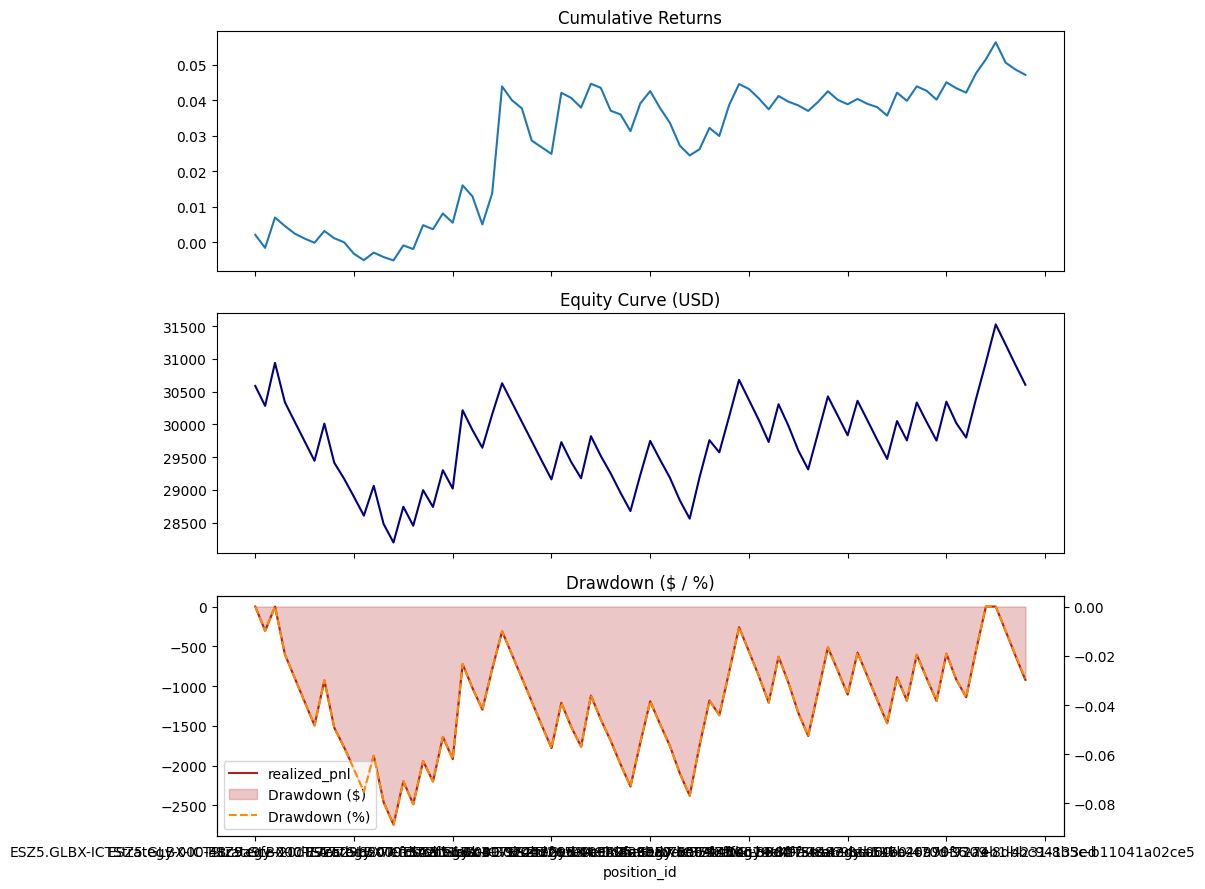

In [9]:
import matplotlib.pyplot as plt


def _money_to_float(series):
    # Convert object/str Money-like series to float values.
    if series.empty:
        return series
    if series.dtype != "O":
        return series
    cleaned = series.astype(str).str.replace(",", "")
    numeric = cleaned.str.split().str[0]
    return pd.to_numeric(numeric, errors="coerce")


positions_report = backtest_engine.trader.generate_positions_report()

if len(positions_report) == 0:
    print("No positions to report.")
else:
    # Cumulative profit in instrument currency
    returns_series = _money_to_float(positions_report["realized_return"])
    returns = returns_series.cumsum()

    # Build equity curve in USD (use realized_pnl if available, otherwise returns)
    starting_balance = 30_000
    if "realized_pnl" in positions_report.columns:
        pnl_series = _money_to_float(positions_report["realized_pnl"])
        equity = pnl_series.cumsum() + starting_balance
    else:
        equity = returns + starting_balance

    peak = equity.cummax()
    drawdown = equity - peak
    drawdown_pct = equity / peak - 1

    print(f"Max drawdown ($): {drawdown.min():,.2f}")
    print(f"Max drawdown (%): {drawdown_pct.min():.2%}")

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    returns.plot(ax=axes[0], title="Cumulative Returns")
    equity.plot(ax=axes[1], color="navy", title="Equity Curve (USD)")

    drawdown.plot(ax=axes[2], color="firebrick", title="Drawdown ($ / %)")
    axes[2].fill_between(drawdown.index, drawdown, 0, color="firebrick", alpha=0.25, label="Drawdown ($)")

    # Twin axis for percentage drawdown overlay
    ax_dd_pct = axes[2].twinx()
    drawdown_pct.plot(ax=ax_dd_pct, color="darkorange", linestyle="--", label="Drawdown (%)")

    # Combine legends for both axes
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax_dd_pct.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc="lower left")

    plt.tight_layout()
    plt.show()
